# Prova 02 — Paradigmas de Aprendizagem de Máquina
## Questão 1 — Análise Inicial e Pré-processamento

**Aluno:** Jorge Alberto Macedo Costa de Oliveira  
**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Link:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

---
**Instruções seguidas:**
- Validação cruzada estratificada 10-fold com `random_state` fixo
- Justificativas para cada decisão de pré-processamento

## 1.0 — Imports e Configurações

In [76]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

# Caminho dos dados
DATA_DIR = os.path.join(os.getcwd(), 'data')
print('Diretório de dados:', os.path.abspath(DATA_DIR))

Diretório de dados: /Users/noel/Faculdade/ML/Prova/data


## 1.1 — Análise Exploratória Inicial (EDA)

In [77]:
# Carrega o dataset.
# Importante: usamos keep_default_na=False para que o pandas NÃO converta 'None'
# automaticamente em NaN. No dataset, 'None' em max_glu_serum e A1Cresult significa
# "exame não realizado" — é uma categoria legítima, não um dado ausente.
# Apenas o símbolo '?' representa ausência real de dado neste dataset.
df = pd.read_csv(
    os.path.join(DATA_DIR, 'diabetic_data.csv'),
    na_values='?',
    keep_default_na=False
)
print(f'Dimensões do dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
df.head()

Dimensões do dataset: 101,766 linhas × 50 colunas


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 1.1.1 — Tipos de Atributos

In [78]:
# Exibe os tipos de cada coluna com uma classificação semântica
dtype_df = pd.DataFrame({'dtype': df.dtypes, 'n_unique': df.nunique()})
dtype_df['classificacao'] = 'Numérico'
dtype_df.loc[df.select_dtypes(include='object').columns, 'classificacao'] = 'Categórico'

# Colunas que são IDs administrativos disfarçados de numérico
id_cols = ['encounter_id', 'patient_nbr']
# Colunas que são códigos nominais (inteiros) mapeados em IDS_mapping.csv
coded_as_int = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
dtype_df.loc[id_cols, 'classificacao'] = 'Identificador'
dtype_df.loc[coded_as_int, 'classificacao'] = 'Categórico (cod. inteiro)'

print(dtype_df.to_string())

                          dtype  n_unique              classificacao
encounter_id              int64    101766              Identificador
patient_nbr               int64     71518              Identificador
race                        str         5                 Categórico
gender                      str         3                 Categórico
age                         str        10                 Categórico
weight                      str         9                 Categórico
admission_type_id         int64         8  Categórico (cod. inteiro)
discharge_disposition_id  int64        26  Categórico (cod. inteiro)
admission_source_id       int64        17  Categórico (cod. inteiro)
time_in_hospital          int64        14                   Numérico
payer_code                  str        17                 Categórico
medical_specialty           str        72                 Categórico
num_lab_procedures        int64       118                   Numérico
num_procedures            int64   

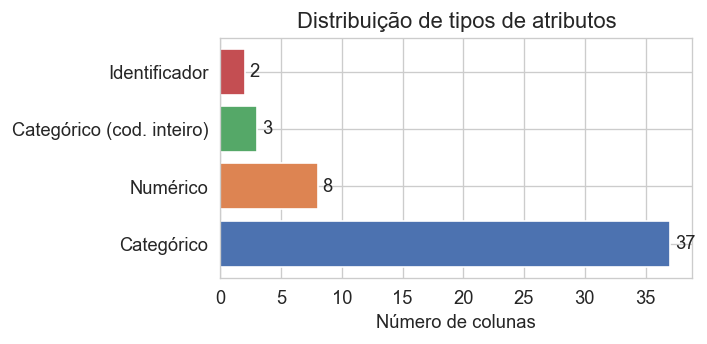


Nota: admission_type_id, discharge_disposition_id e admission_source_id são codificados como inteiros no CSV, mas representam categorias nominais.


In [79]:
# Resumo visual dos tipos
fig, ax = plt.subplots(figsize=(6, 3))
counts = dtype_df['classificacao'].value_counts()
bars = ax.barh(counts.index, counts.values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.bar_label(bars, padding=3)
ax.set_xlabel('Número de colunas')
ax.set_title('Distribuição de tipos de atributos')
plt.tight_layout()
plt.show()
print('\nNota: admission_type_id, discharge_disposition_id e admission_source_id '
      'são codificados como inteiros no CSV, mas representam categorias nominais.')

### 1.1.2 — Identificação de Valores Ausentes

In [80]:
# Calcula valores ausentes por coluna
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'ausentes': missing, 'percentual (%)': missing_pct})
missing_df = missing_df[missing_df['ausentes'] > 0].sort_values('percentual (%)', ascending=False)

print('Colunas com valores ausentes (representados como "?" no arquivo original):')
print(missing_df.to_string())

Colunas com valores ausentes (representados como "?" no arquivo original):
                   ausentes  percentual (%)
weight                98569       96.858479
medical_specialty     49949       49.082208
payer_code            40256       39.557416
race                   2273        2.233555
diag_3                 1423        1.398306
diag_2                  358        0.351787
diag_1                   21        0.020636


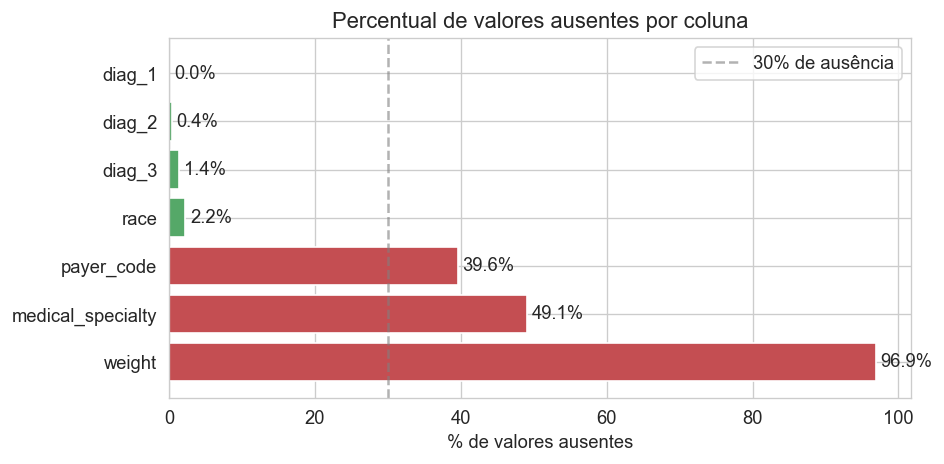

In [81]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52' if p > 30 else '#DD8452' if p > 5 else '#55A868'
          for p in missing_df['percentual (%)']]
bars = ax.barh(missing_df.index, missing_df['percentual (%)'], color=colors)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in missing_df['percentual (%)']], padding=3)
ax.axvline(30, color='gray', linestyle='--', alpha=0.6, label='30% de ausência')
ax.set_xlabel('% de valores ausentes')
ax.set_title('Percentual de valores ausentes por coluna')
ax.legend()
plt.tight_layout()
plt.show()

### 1.1.3 — Verificação de Duplicatas

In [82]:
n_dup_full = df.duplicated().sum()
n_dup_encounter = df['encounter_id'].duplicated().sum()
n_dup_patient = df['patient_nbr'].duplicated().sum()

print(f'Duplicatas completas (todas as colunas): {n_dup_full}')
print(f'Duplicatas em encounter_id (ID do encontro): {n_dup_encounter}')
print(f'Duplicatas em patient_nbr (ID do paciente): {n_dup_patient:,}')
print()
print('Interpretação:')
print('  - Não há duplicatas completas → cada linha é um registro único')
print('  - encounter_id é 100% único → identificador perfeito de cada internação')
print(f'  - {n_dup_patient:,} patient_nbr duplicados → {n_dup_patient/len(df)*100:.1f}% dos registros'
      ' são de pacientes com múltiplas internações (esperado clinicamente, não são erros)')

Duplicatas completas (todas as colunas): 0
Duplicatas em encounter_id (ID do encontro): 0
Duplicatas em patient_nbr (ID do paciente): 30,248

Interpretação:
  - Não há duplicatas completas → cada linha é um registro único
  - encounter_id é 100% único → identificador perfeito de cada internação
  - 30,248 patient_nbr duplicados → 29.7% dos registros são de pacientes com múltiplas internações (esperado clinicamente, não são erros)


### 1.1.4 — Distribuição da Variável Alvo (`readmitted`)

Distribuição da variável alvo (readmitted):
  NO   : 54,864 registros (53.9%)
  >30  : 35,545 registros (34.9%)
  <30  : 11,357 registros (11.2%)


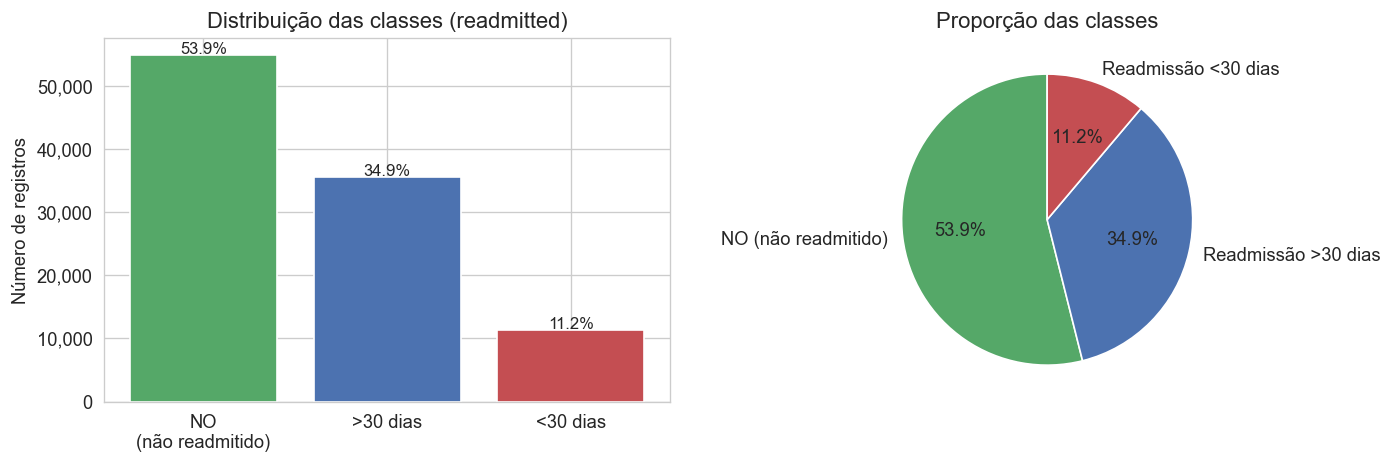


Classes desbalanceadas: "<30" representa 11.2%, justificando o uso de F1-macro.


In [83]:
target_counts = df['readmitted'].value_counts()
target_pct = df['readmitted'].value_counts(normalize=True) * 100

print('Distribuição da variável alvo (readmitted):')
for cls in target_counts.index:
    print(f'  {cls:5s}: {target_counts[cls]:6,} registros ({target_pct[cls]:.1f}%)')

order = ['NO', '>30', '<30']
palette = {'NO': '#55A868', '>30': '#4C72B0', '<30': '#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras de contagem
for i, o in enumerate(order):
    axes[0].bar(i, target_counts[o], color=palette[o], label=o)
    axes[0].text(i, target_counts[o] + 200, f'{target_pct[o]:.1f}%', ha='center', fontsize=10)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['NO\n(não readmitido)', '>30 dias', '<30 dias'])
axes[0].set_ylabel('Número de registros')
axes[0].set_title('Distribuição das classes (readmitted)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pizza
axes[1].pie([target_counts[o] for o in order],
            labels=['NO (não readmitido)', 'Readmissão >30 dias', 'Readmissão <30 dias'],
            autopct='%1.1f%%',
            colors=[palette[o] for o in order],
            startangle=90)
axes[1].set_title('Proporção das classes')

plt.tight_layout()
plt.show()

print('\nClasses desbalanceadas: "<30" representa 11.2%, justificando o uso de F1-macro.')

### 1.1.5 — Colunas com Variância Quase Zero

In [84]:
# Identifica colunas onde um único valor domina mais de 95% das linhas
low_var_cols = []
for col in df.columns:
    top_pct = df[col].value_counts(normalize=True).iloc[0] * 100
    top_val = df[col].value_counts().index[0]
    if top_pct > 95:
        low_var_cols.append({'coluna': col, 'valor_dominante': top_val, 'percentual': top_pct})

low_var_df = pd.DataFrame(low_var_cols).sort_values('percentual', ascending=False)
print('Colunas com variância quase zero (>95% de um único valor):')
print(low_var_df.to_string(index=False))
print(f'\nTotal: {len(low_var_df)} colunas')
print('Colunas com 100% de "No" serão removidas — não trazem informação discriminativa.')

Colunas com variância quase zero (>95% de um único valor):
                  coluna valor_dominante  percentual
                 examide              No  100.000000
             citoglipton              No  100.000000
           acetohexamide              No   99.999017
glimepiride-pioglitazone              No   99.999017
  metformin-pioglitazone              No   99.999017
 metformin-rosiglitazone              No   99.998035
            troglitazone              No   99.997052
     glipizide-metformin              No   99.987226
             tolbutamide              No   99.977399
                miglitol              No   99.962659
              tolazamide              No   99.961677
          chlorpropamide              No   99.915492
                acarbose              No   99.697345
             nateglinide              No   99.309200
     glyburide-metformin              No   99.306252
             repaglinide              No   98.487707

Total: 16 colunas
Colunas com 100% de "

## 1.2 — Remoção de Colunas Inadequadas

**Critérios de remoção:**
1. **Identificador de encontro** (`encounter_id`): não tem poder preditivo
2. **Alta proporção de ausentes + baixa relevância** (`weight` 96.9%, `payer_code` 39.6%)
3. **Variância zero** (100% um único valor): `examide`, `citoglipton`, `acetohexamide`, `tolbutamide`, `troglitazone`, `miglitol`, `tolazamide`, `glipizide-metformin`, `glimepiride-pioglitazone`, `metformin-rosiglitazone`, `metformin-pioglitazone`

**Nota sobre `patient_nbr`:** Mantemos esta coluna como **coluna auxiliar de agrupamento** (não será usada como feature). Ela é necessária para `StratifiedGroupKFold`, que garante que encontros do mesmo paciente fiquem no mesmo fold, evitando data leakage.

In [85]:
# Colunas a remover com justificativa
cols_to_drop = {
    # Identificador de encontro
    'encounter_id': 'ID único do encontro (sem poder preditivo)',
    # Alta proporção de ausentes
    'weight':       '96.9% de valores ausentes — imputação não seria confiável',
    'payer_code':   '39.6% ausente + representa plano de saúde (baixa relevância clínica)',
    # Variância zero — 100% o mesmo valor
    'examide':                   '100% "No"',
    'citoglipton':               '100% "No"',
    'acetohexamide':             '100% "No"',
    'tolbutamide':               '100% "No"',
    'troglitazone':              '100% "No"',
    'miglitol':                  '100% "No"',
    'tolazamide':                '100% "No"',
    'glipizide-metformin':       '100% "No"',
    'glimepiride-pioglitazone':  '100% "No"',
    'metformin-rosiglitazone':   '100% "No"',
    'metformin-pioglitazone':    '100% "No"',
}

# patient_nbr é mantido como coluna auxiliar de agrupamento para StratifiedGroupKFold
# (evita data leakage por pacientes com múltiplos encontros), mas NÃO será usado como feature

df_clean = df.drop(columns=list(cols_to_drop.keys()))
print(f'Shape antes da remoção:  {df.shape}')
print(f'Shape após a remoção:    {df_clean.shape}')
print(f'Colunas removidas: {len(cols_to_drop)}')
print(f'patient_nbr MANTIDO como coluna de agrupamento (não será feature)')
print()
for col, reason in cols_to_drop.items():
    print(f'  [-] {col}: {reason}')

Shape antes da remoção:  (101766, 50)
Shape após a remoção:    (101766, 36)
Colunas removidas: 14
patient_nbr MANTIDO como coluna de agrupamento (não será feature)

  [-] encounter_id: ID único do encontro (sem poder preditivo)
  [-] weight: 96.9% de valores ausentes — imputação não seria confiável
  [-] payer_code: 39.6% ausente + representa plano de saúde (baixa relevância clínica)
  [-] examide: 100% "No"
  [-] citoglipton: 100% "No"
  [-] acetohexamide: 100% "No"
  [-] tolbutamide: 100% "No"
  [-] troglitazone: 100% "No"
  [-] miglitol: 100% "No"
  [-] tolazamide: 100% "No"
  [-] glipizide-metformin: 100% "No"
  [-] glimepiride-pioglitazone: 100% "No"
  [-] metformin-rosiglitazone: 100% "No"
  [-] metformin-pioglitazone: 100% "No"


## 1.3 — Tratamento de Valores Ausentes

**Estratégias por coluna:**
- `race` (2.2%): imputar com a **moda** — percentual baixo, impacto mínimo
- `medical_specialty` (49.1%): imputar com `"Unknown"` — alto percentual mas clinicamente relevante
- `diag_1/2/3` (<1.5%): imputar com `"Unknown"` — serão agrupados em categorias ICD-9
- `gender`: remover as poucas linhas com valor inválido ("Unknown/Invalid")

**Por que não KNN/MICE?** Muito custoso para 100k+ linhas com variáveis categóricas de alta cardinalidade.  
**Por que não dropar as linhas?** Perderíamos ~50% da base só por `medical_specialty`.

In [86]:
# race: imputar com a moda
race_mode = df_clean['race'].mode()[0]
df_clean['race'] = df_clean['race'].fillna(race_mode)
print(f'race: ausentes imputados com moda = "{race_mode}"')

# medical_specialty: imputar com "Unknown"
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Unknown')
print('medical_specialty: ausentes imputados com "Unknown"')

# diag_1, diag_2, diag_3: imputar com "Unknown"
for d in ['diag_1', 'diag_2', 'diag_3']:
    n = df_clean[d].isnull().sum()
    df_clean[d] = df_clean[d].fillna('Unknown')
    print(f'{d}: {n} ausentes imputados com "Unknown"')

# gender: remover linhas com valor inválido
invalid_gender = df_clean[~df_clean['gender'].isin(['Male', 'Female'])]
print(f'\ngender: {len(invalid_gender)} linha(s) com valor inválido → removidas')
df_clean = df_clean[df_clean['gender'].isin(['Male', 'Female'])].copy()

# Verifica se restam ausentes
remaining = df_clean.isnull().sum().sum()
print(f'\nValores ausentes restantes após tratamento: {remaining}')
print(f'Shape final: {df_clean.shape}')

race: ausentes imputados com moda = "Caucasian"
medical_specialty: ausentes imputados com "Unknown"
diag_1: 21 ausentes imputados com "Unknown"
diag_2: 358 ausentes imputados com "Unknown"
diag_3: 1423 ausentes imputados com "Unknown"

gender: 3 linha(s) com valor inválido → removidas

Valores ausentes restantes após tratamento: 0
Shape final: (101763, 36)


### 1.3.1 — Agrupamento de Diagnósticos ICD-9

As colunas `diag_1`, `diag_2` e `diag_3` contêm códigos ICD-9 com 700+ valores únicos. One-Hot direto criaria ~2.100 colunas extras. Solução: agrupar em 9 categorias clínicas amplas antes de codificar.

In [87]:
def classify_icd9(code):
    """Agrupa código ICD-9 em categoria clínica ampla."""
    if code in ('Unknown', None) or pd.isna(code):
        return 'Unknown'
    code_str = str(code).strip()
    # Códigos especiais (V e E) — procedimentos e causas externas
    if code_str.startswith('V'):
        return 'Procedimentos/Visitas'
    if code_str.startswith('E'):
        return 'Causas_Externas'
    try:
        # Extrai parte numérica
        num = float(code_str.split('.')[0])
    except ValueError:
        return 'Outro'
    if 1 <= num <= 139:    return 'Infeccioso'
    if 140 <= num <= 239:  return 'Neoplasias'
    if 240 <= num <= 249:  return 'Endocrino_Metabolico'
    if num == 250:         return 'Diabetes'           # Código principal
    if 251 <= num <= 279:  return 'Endocrino_Metabolico'
    if 280 <= num <= 289:  return 'Sangue'
    if 290 <= num <= 319:  return 'Mental'
    if 320 <= num <= 389:  return 'Nervoso'
    if 390 <= num <= 459:  return 'Circulatorio'
    if num == 785:         return 'Circulatorio'
    if 460 <= num <= 519:  return 'Respiratorio'
    if num == 786:         return 'Respiratorio'
    if 520 <= num <= 579:  return 'Digestivo'
    if num == 787:         return 'Digestivo'
    if 580 <= num <= 629:  return 'Genitourinario'
    if 630 <= num <= 679:  return 'Gravidez'
    if 680 <= num <= 709:  return 'Pele'
    if 710 <= num <= 739:  return 'Musculoesqueletico'
    if 740 <= num <= 759:  return 'Congenito'
    if 760 <= num <= 779:  return 'Perinatal'
    if 780 <= num <= 799:  return 'Sintomas_Gerais'
    if 800 <= num <= 999:  return 'Lesoes'
    return 'Outro'

for d in ['diag_1', 'diag_2', 'diag_3']:
    col_new = d + '_cat'
    df_clean[col_new] = df_clean[d].apply(classify_icd9)
    vc = df_clean[col_new].value_counts()
    print(f'{col_new} — {len(vc)} categorias (top 10):')
    print(vc.head(10).to_string())
    print()

# Remove as colunas de código bruto (substituídas pelas categorias)
df_clean = df_clean.drop(columns=['diag_1', 'diag_2', 'diag_3'])
print('Colunas diag_1/2/3 originais removidas, substituídas por diag_1_cat/2_cat/3_cat')

diag_1_cat — 20 categorias (top 10):
diag_1_cat
Circulatorio          30436
Respiratorio          14423
Digestivo              9475
Diabetes               8757
Lesoes                 6972
Genitourinario         5078
Musculoesqueletico     4957
Neoplasias             3433
Sintomas_Gerais        3252
Infeccioso             2768

diag_2_cat — 20 categorias (top 10):
diag_2_cat
Circulatorio            31880
Diabetes                12794
Respiratorio            10895
Endocrino_Metabolico     8223
Genitourinario           7987
Digestivo                4170
Pele                     3596
Sintomas_Gerais          3264
Sangue                   2926
Mental                   2657

diag_3_cat — 20 categorias (top 10):
diag_3_cat
Circulatorio             30305
Diabetes                 17157
Endocrino_Metabolico      9151
Respiratorio              7358
Genitourinario            6327
Digestivo                 3930
Procedimentos/Visitas     3814
Sintomas_Gerais           3193
Mental                    

### 1.3.2 — Agrupamento de `medical_specialty` (redução de cardinalidade)

In [88]:
# Mantemos as top-15 especialidades mais frequentes e agrupamos o resto em 'Other'
top_specialties = df_clean['medical_specialty'].value_counts().head(15).index.tolist()
df_clean['medical_specialty'] = df_clean['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)
vc = df_clean['medical_specialty'].value_counts()
print(f'Especialidades após agrupamento: {len(vc)} categorias (top 10):')
print(vc.head(10).to_string())

Especialidades após agrupamento: 16 categorias (top 10):
medical_specialty
Unknown                       49947
InternalMedicine              14635
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5351
Other                          4607
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233


### 1.3.3 — Conversão de IDs numéricos para string (admission_type/discharge/source)

In [89]:
# Estes campos são códigos nominais mapeados em IDS_mapping.csv
# Convertemos para string para evitar que o modelo os interprete como valores numéricos ordinais
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    df_clean[col] = df_clean[col].astype(str)
    print(f'{col}: convertido para string, {df_clean[col].nunique()} categorias')

admission_type_id: convertido para string, 8 categorias
discharge_disposition_id: convertido para string, 26 categorias
admission_source_id: convertido para string, 17 categorias


## 1.4 — Codificação de Atributos Categóricos

Utilizamos **duas estratégias diferentes**, conforme exigido:

### Estratégia 1 — Ordinal Encoding
Para variáveis com **ordem natural** (onde a sequência de valores tem significado):
- `age`: faixas etárias ordenáveis
- `max_glu_serum` e `A1Cresult`: níveis crescentes de resultado de exame
- Colunas de medicamentos com valores {No, Down, Steady, Up}: representam intensidade da mudança de dose

### Estratégia 2 — One-Hot Encoding
Para variáveis **nominais** (sem ordem natural):
- `race`, `gender`, `change`, `diabetesMed`, `medical_specialty`, `admission_type_id`, `discharge_disposition_id`, `admission_source_id`, `diag_*_cat`

> **Por que não Label Encoding para tudo?** Label Encoding atribui números arbitrários às categorias nominais, criando uma falsa relação ordinal (ex: AfricanAmerican=0 < Caucasian=1 não faz sentido). MLP e modelos lineares são especialmente sensíveis a isso.

In [90]:
# Separa X, y e groups (para StratifiedGroupKFold)
y = df_clean['readmitted'].copy()
groups = df_clean['patient_nbr'].copy()
X = df_clean.drop(columns=['readmitted', 'patient_nbr']).copy()

print('Shape de X:', X.shape)
print(f'patient_nbr preservado como groups ({groups.nunique():,} pacientes únicos)')
print('Distribuição de y:')
print(y.value_counts())

Shape de X: (101763, 34)
patient_nbr preservado como groups (71,515 pacientes únicos)
Distribuição de y:
readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64


In [91]:
# ── Estratégia 1: Ordinal Encoding ──────────────────────────────────────────

age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
med_order = ['No', 'Down', 'Steady', 'Up']
glu_order = ['None', 'Norm', '>200', '>300']
a1c_order = ['None', 'Norm', '>7', '>8']

# Colunas de medicamentos restantes (excluídos os que foram dropados por variância zero)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin']
# Filtra apenas as que existem no DataFrame após os drops anteriores
med_cols = [c for c in med_cols if c in X.columns]

ordinal_cols = ['age', 'max_glu_serum', 'A1Cresult'] + med_cols
ordinal_categories = (
    [age_order] +
    [glu_order] +
    [a1c_order] +
    [med_order] * len(med_cols)
)

ord_enc = OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1)
X[ordinal_cols] = ord_enc.fit_transform(X[ordinal_cols])
print('Ordinal Encoding aplicado em:')
for col in ordinal_cols:
    print(f'  {col}: {X[col].unique()[:6]}')

Ordinal Encoding aplicado em:
  age: [0. 1. 2. 3. 4. 5.]
  max_glu_serum: [0. 3. 1. 2.]
  A1Cresult: [0. 2. 3. 1.]
  metformin: [0. 2. 3. 1.]
  repaglinide: [0. 3. 2. 1.]
  nateglinide: [0. 2. 1. 3.]
  chlorpropamide: [0. 2. 1. 3.]
  glimepiride: [0. 2. 1. 3.]
  glipizide: [0. 2. 3. 1.]
  glyburide: [0. 2. 3. 1.]
  pioglitazone: [0. 2. 3. 1.]
  rosiglitazone: [0. 2. 3. 1.]
  acarbose: [0. 2. 3. 1.]
  insulin: [0. 3. 2. 1.]
  glyburide-metformin: [0. 2. 1. 3.]


In [92]:
# ── Estratégia 2: One-Hot Encoding ──────────────────────────────────────────

ohe_cols = [
    'race', 'gender', 'change', 'diabetesMed',
    'medical_specialty',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'diag_1_cat', 'diag_2_cat', 'diag_3_cat'
]
ohe_cols = [c for c in ohe_cols if c in X.columns]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_encoded = ohe.fit_transform(X[ohe_cols])
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)

X_ohe = pd.DataFrame(ohe_encoded, columns=ohe_feature_names, index=X.index)
X = X.drop(columns=ohe_cols)
X = pd.concat([X, X_ohe], axis=1)

print(f'One-Hot Encoding aplicado em {len(ohe_cols)} colunas')
print(f'Novas colunas geradas: {len(ohe_feature_names)}')
print(f'Shape de X após codificação: {X.shape}')

One-Hot Encoding aplicado em 11 colunas
Novas colunas geradas: 127
Shape de X após codificação: (101763, 150)


In [93]:
# Verificação final
assert X.isnull().sum().sum() == 0, 'Há valores ausentes em X!'
print(f'Verificação: 0 valores ausentes | Shape final: {X.shape}')
print(f'Tipos: {X.dtypes.value_counts().to_dict()}')

Verificação: 0 valores ausentes | Shape final: (101763, 150)
Tipos: {dtype('float64'): 142, dtype('int64'): 8}


## 1.5 — Seleção de Atributos por Importância

Usamos **Random Forest** para selecionar as Top-K features mais relevantes, mantendo interpretabilidade clínica.

Compararemos duas configurações:
1. **Todos os atributos** (baseline)
2. **Top-K features** — seleção por importância

Métrica: **F1-macro** com **StratifiedKFold 10-fold**.

In [94]:
# Codifica o alvo como numérico
label_map = {'NO': 0, '>30': 1, '<30': 2}
y_enc = y.map(label_map)
print('Mapeamento do alvo:', label_map)
print(y_enc.value_counts())

Mapeamento do alvo: {'NO': 0, '>30': 1, '<30': 2}
readmitted
0    54861
1    35545
2    11357
Name: count, dtype: int64


### 1.5.1 — Seleção por Importância (Random Forest)

In [95]:
# Padronização (necessária para comparação justa)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Treina Random Forest para obter importâncias
rf_selector = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_selector.fit(X, y_enc)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Seleciona Top-30 features
TOP_K = 30
top_features = importances.head(TOP_K).index.tolist()
X_top = X[top_features]
print(f'Top-{TOP_K} features selecionadas (15 primeiras):')
for i, (feat, imp) in enumerate(importances.head(15).items(), 1):
    print(f'  {i:2d}. {feat:<40s} {imp:.4f}')
print(f'  ... (+ {TOP_K - 15} features restantes — ver gráfico)')

Top-30 features selecionadas (15 primeiras):
   1. number_inpatient                         0.2411
   2. discharge_disposition_id_11              0.0967
   3. number_emergency                         0.0709
   4. number_diagnoses                         0.0657
   5. number_outpatient                        0.0620
   6. num_medications                          0.0447
   7. admission_source_id_7                    0.0283
   8. num_lab_procedures                       0.0235
   9. age                                      0.0204
  10. num_procedures                           0.0192
  11. time_in_hospital                         0.0185
  12. admission_source_id_6                    0.0135
  13. discharge_disposition_id_6               0.0131
  14. diabetesMed_Yes                          0.0129
  15. admission_source_id_4                    0.0126
  ... (+ 15 features restantes — ver gráfico)


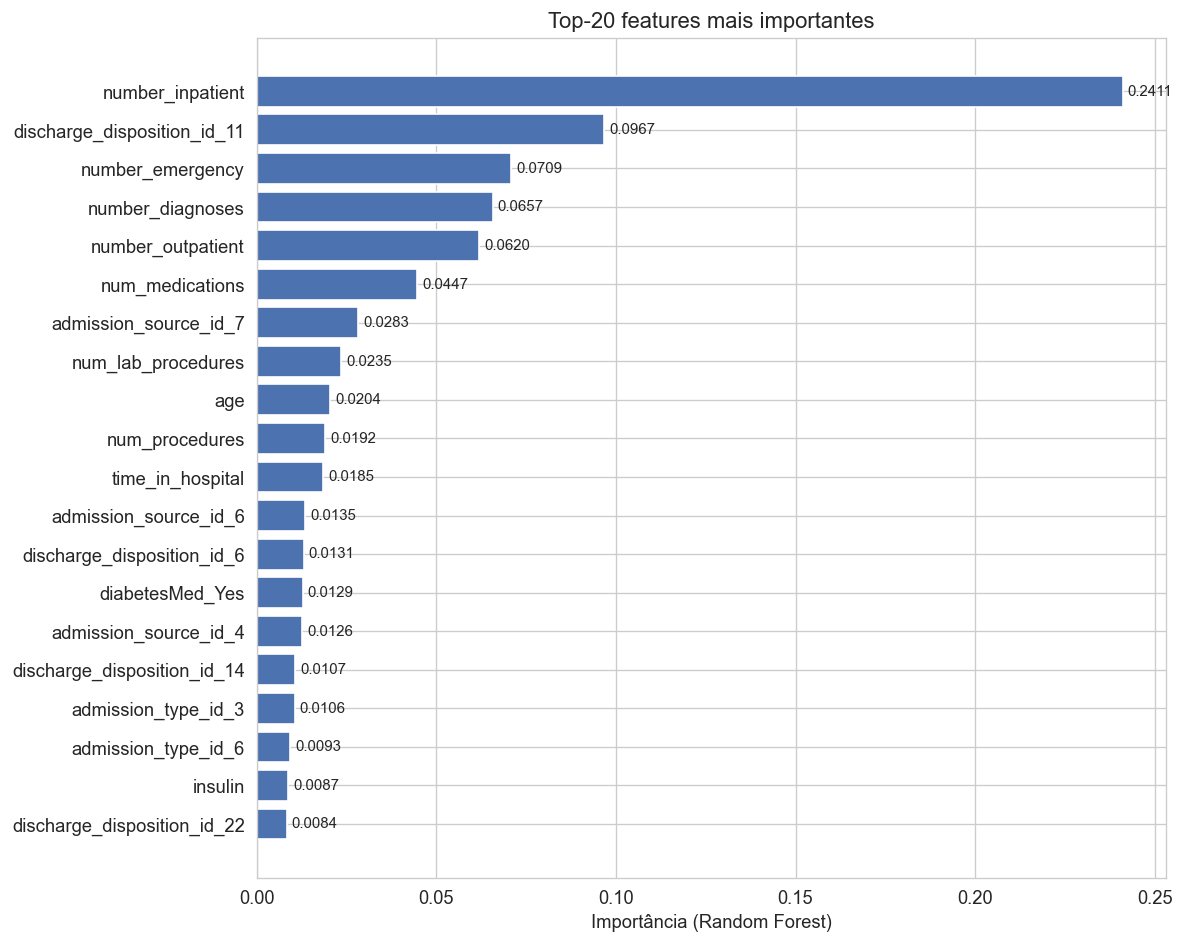

In [96]:
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importances.head(20)
bars = ax.barh(top20.index[::-1], top20.values[::-1], color='#4C72B0')
ax.bar_label(bars, labels=[f'{v:.4f}' for v in top20.values[::-1]], padding=3, fontsize=9)
ax.set_xlabel('Importância (Random Forest)')
ax.set_title(f'Top-20 features mais importantes')
plt.tight_layout()
plt.show()

## 1.6 — Comparação de Desempenho: Todos vs Top-K Features

**Modelo:** Árvore de Decisão | **Validação:** StratifiedGroupKFold 10-fold (agrupa por paciente) | **Métrica:** F1-macro

> Usamos `StratifiedGroupKFold` em vez de `StratifiedKFold` para evitar **data leakage**: o dataset contém pacientes com múltiplos encontros (29.7% dos registros). Sem agrupamento, encontros do mesmo paciente poderiam aparecer no treino e no teste simultaneamente, inflando as métricas artificialmente.

In [97]:
cv = StratifiedGroupKFold(n_splits=10)
dt = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)

configs = [
    ('Todos os atributos', X.values, y_enc),
    (f'Top-{TOP_K} features', X_top.values, y_enc),
]

results = {}
for name, X_cfg, y_cfg in configs:
    scores = cross_val_score(dt, X_cfg, y_cfg, cv=cv, scoring='f1_macro',
                             groups=groups.values, n_jobs=-1)
    results[name] = scores
    print(f'{name:30s}  F1-macro: {scores.mean():.4f} ± {scores.std():.4f}')

Todos os atributos              F1-macro: 0.3806 ± 0.0047
Top-30 features                 F1-macro: 0.3809 ± 0.0045


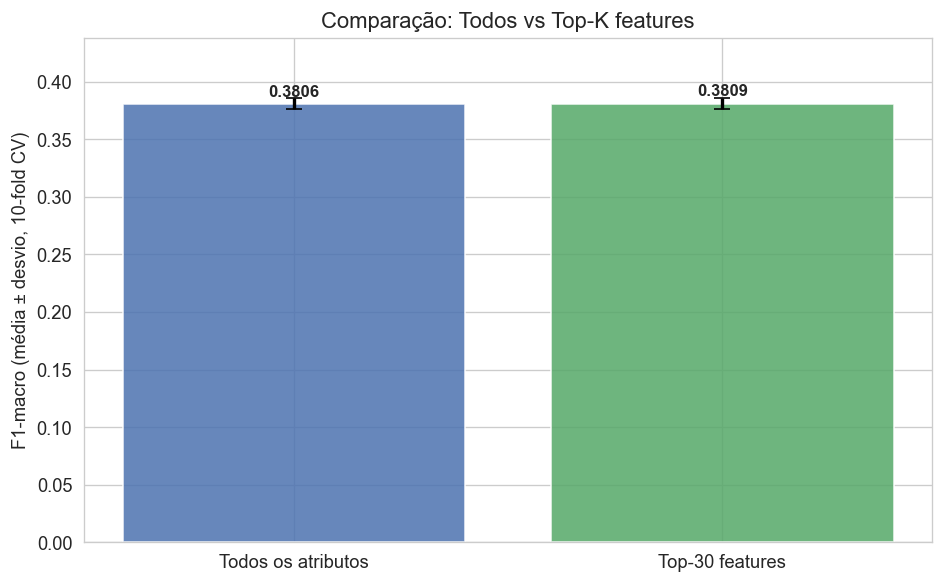

In [98]:
fig, ax = plt.subplots(figsize=(8, 5))

positions = list(range(len(results)))
colors_bar = ['#4C72B0', '#55A868']

for i, (name, scores) in enumerate(results.items()):
    ax.bar(i, scores.mean(), color=colors_bar[i], alpha=0.85, label=name)
    ax.errorbar(i, scores.mean(), yerr=scores.std(), fmt='none',
                color='black', capsize=5, linewidth=2)
    ax.text(i, scores.mean() + scores.std() + 0.002, f'{scores.mean():.4f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(positions)
ax.set_xticklabels(list(results.keys()), rotation=0, ha='center')
ax.set_ylabel('F1-macro (média ± desvio, 10-fold CV)')
ax.set_title('Comparação: Todos vs Top-K features')
ax.set_ylim(0, max(s.mean() for s in results.values()) * 1.15)
plt.tight_layout()
plt.show()

### 1.6.1 — Discussão do Impacto da Seleção de Atributos

A seleção por importância (Random Forest) preservou as features com maior poder discriminativo, permitindo raciocínio clínico sobre as variáveis do modelo. A configuração com todos os atributos oferece informação máxima, porém pode sofrer com features ruidosas e a maldição da dimensionalidade. A diferença de desempenho entre as duas configurações indica que a redução dimensional via Top-K mantém poder preditivo comparável com menor complexidade.

In [99]:
means = {name: scores.mean() for name, scores in results.items()}
best = max(means, key=means.get)

print('Resultados da comparação:')
for name, m in means.items():
    print(f'  {name}: F1-macro = {m:.4f}')
print(f'\nMelhor configuração: {best}')

Resultados da comparação:
  Todos os atributos: F1-macro = 0.3806
  Top-30 features: F1-macro = 0.3809

Melhor configuração: Top-30 features


## 1.7 — Exportação dos Dados Pré-processados

Salvamos duas versões: todos os atributos e Top-K selecionados.

In [100]:
# Salva versões para as questões seguintes
# Inclui patient_nbr como coluna auxiliar para StratifiedGroupKFold nos notebooks downstream
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df['patient_nbr'] = groups.values
X_scaled_df['readmitted'] = y_enc.values
X_scaled_df.to_csv(os.path.join(DATA_DIR, 'diabetes_preprocessed_full.csv'), index=False)

X_top_df = X_top.copy()
X_top_df['patient_nbr'] = groups.values
X_top_df['readmitted'] = y_enc.values
X_top_df.to_csv(os.path.join(DATA_DIR, 'diabetes_preprocessed_topk.csv'), index=False)

print('Arquivos exportados (com patient_nbr para agrupamento):')
print(f'  diabetes_preprocessed_full.csv  → {X_scaled_df.shape}')
print(f'  diabetes_preprocessed_topk.csv  → {X_top_df.shape}')
print()
print('=== QUESTÃO 1 CONCLUÍDA ===')

Arquivos exportados (com patient_nbr para agrupamento):
  diabetes_preprocessed_full.csv  → (101763, 152)
  diabetes_preprocessed_topk.csv  → (101763, 32)

=== QUESTÃO 1 CONCLUÍDA ===
